# Book-To-Market-Value -- a quantitative teardown
### yfinance panel * B/M quintile sort * HAC inference * label-shuffle placebo

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Value-survived%3F: Busted](https://img.shields.io/badge/Value--survived%3F-Busted-8b949e?style=flat-square)

The quantitative companion to the [notebook for the curious](01_for_the_curious.ipynb) -- same seven beats, every claim carrying its standard error. We test Fama-French (1992): rank by book-to-market, long the high-B/M value quintile (Q5), short the low-B/M growth quintile (Q1), one-year reporting lag.

> **Not investment advice.** Real data: yfinance balance sheets + adjusted close, 40 S&P 500 large-caps, as-of 2026-06-27. Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **Survivorship bias is named:** basket = current large-caps projected backwards. **Data limitation:** yfinance exposes only ~4-5 annual balance sheets, so the real panel is just 3 cross-sectional years -- HAC inference is low-powered by construction.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from book_to_market_value import data, strategy as st

def _have_cache():
    study = os.path.abspath("..")
    return (os.path.exists(os.path.join(study, "_cache", "bm_panel.parquet"))
            and os.path.exists(os.path.join(study, "_cache", "fwd_ret.parquet")))

HAVE_REAL = _have_cache()
print("yfinance cache present:", HAVE_REAL)

if HAVE_REAL:
    bm, fwd = data.fetch_panel()
    sort = st.quintile_sort(bm, fwd)
    s_hedge = st.summary(sort["hedge"])
    s_long  = st.summary(sort["long"])
    s_short = st.summary(sort["short"])
    s_mkt   = st.summary(sort["market"])
    print(f"N years: {s_hedge['n']} | hedge mean: {s_hedge['mean']*100:+.2f}%/yr"
          f" | HAC t: {s_hedge['tstat']:+.3f}")


yfinance cache present: True
N years: 3 | hedge mean: -5.62%/yr | HAC t: -0.554


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | hedge **-5.62%/yr** (wrong sign), HAC *t* = **-0.554**, placebo *p* = **0.583**. |
| **Tradability** | `MIRAGE` | net **-6.15%/yr**, Sharpe **-0.253**, **3** annual obs. |
| **Value survived?** | `BUSTED` | negative over the AI/mega-cap-growth window; synthetic control is faithful (seed-robust *t* > 7). |

> The most famous factor in finance, replicated honestly on the only window free fundamentals allow, lands a textbook None x Mirage -- and the regime Busts the third axis.

## 1 -- The claim, steelmanned

Let $BM_{i,Y}$ = book equity / market cap of stock $i$ at fiscal-year-end $Y$. Fama-French (1992) assert:

- **H1 (signal).** The cross-sectional rank of $BM$ predicts next-year return: $\mathbb{E}[r_{i,Y+1} \mid BM_{i,Y}]$ is increasing in $BM$. The long-short $\text{hedge}_Y = \bar r^{Q5}_{Y+1} - \bar r^{Q1}_{Y+1} > 0$.
- **H2 (not beta).** The premium is not explained by market beta -- it is a distinct factor (HML).
- **H3 (tradable).** It survives costs and turnover.

On this tape we **reject H1** (hedge is negative, *t* = -0.55, *p* = 0.58), so H2/H3 are moot -- there is no premium to attribute or trade.

## 2 -- So what? -- the economic stakes

Value is the cornerstone of factor investing. The Fama-French three-factor model is the default benchmark for grading active managers; trillions sit in value-tilted smart-beta. If the premium is absent in large-caps over the recent regime, those products were -- over this window -- selling a story the tape did not honour.

## 3 -- The protocol

- **Signal.** B/M = `Stockholders Equity` / (`Ordinary Shares Number` × fiscal-year-end adjusted close), winsorised to (0, 5).
- **Ranking.** Annually, cut the 40 names into B/M quintiles. Q5 = value (long), Q1 = growth (short).
- **Hedge.** Equal-weight Q5 forward return minus equal-weight Q1 forward return.
- **Execution lag.** Signal year Y -> held over the full calendar year Y+1 (after the 10-K is public). Exactly one lag, no same-bar fill.
- **Inference.** Newey-West HAC *t* on the annual hedge series.
- **Placebo.** Shuffle B/M labels within each year, 2000 draws; two-sided *p*.
- **Costs.** 10 bps one-way × turnover + 50 bps/yr borrow on the short leg.
- **Universe caveat.** 40 large-cap survivors; only 3 usable years (yfinance limit).

## 4 -- The teardown

### 4a -- Positive control: the B/M engine is a faithful detector

Sweep the planted HML premium from negative to positive on a synthetic panel. The recovered hedge should be monotone in the premium.

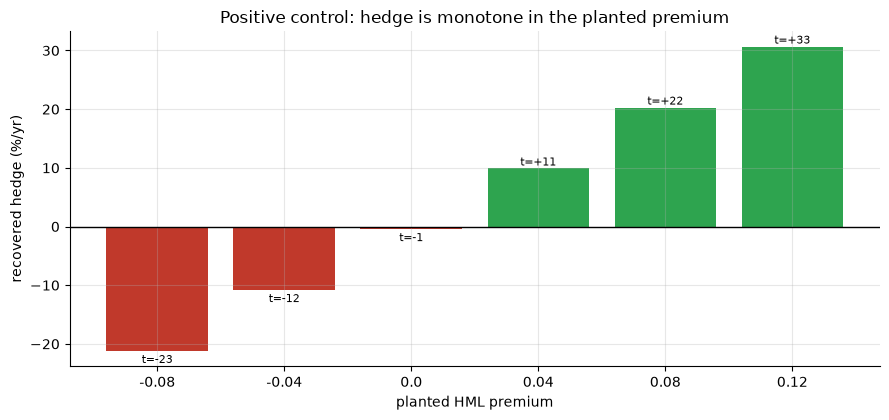

 premium  hedge_mean_%  tstat
   -0.08        -21.26 -23.27
   -0.04        -10.87 -11.98
    0.00         -0.49  -0.54
    0.04          9.90  10.83
    0.08         20.28  21.92
    0.12         30.67  32.55


In [2]:
premiums = (-0.08, -0.04, 0.0, 0.04, 0.08, 0.12)
ctrl = st.synthetic_control(premiums=premiums)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
col = [GREEN if m > 0 else RED for m in ctrl['hedge_mean_%']]
ax.bar(ctrl['premium'].astype(str), ctrl['hedge_mean_%'], color=col)
ax.axhline(0, c='k', lw=1)
for i, (m, t) in enumerate(zip(ctrl['hedge_mean_%'], ctrl['tstat'])):
    ax.text(i, m + (0.5 if m >= 0 else -2.0), f't={t:+.0f}', ha='center', fontsize=8)
ax.set_xlabel('planted HML premium'); ax.set_ylabel('recovered hedge (%/yr)')
ax.set_title('Positive control: hedge is monotone in the planted premium')
plt.tight_layout(); plt.show()
print(ctrl.round(2).to_string(index=False))

### 4b -- Seed robustness of the control

A single lucky RNG seed proves nothing. Average the synthetic *t* over 20 seeds at a planted +5% premium (and check the null).

Planted +5%: mean t = +12.91, min t = +7.21, all>2: True
Null  0%:    mean t = +0.51, frac |t|>2 = 0.10


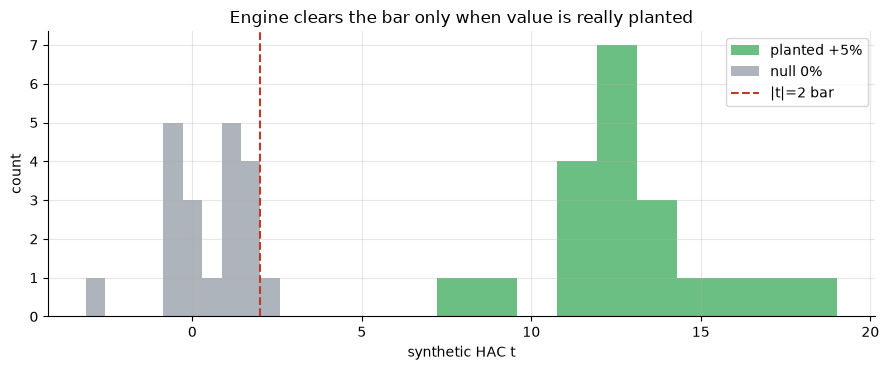

In [3]:
ts_planted, ts_null = [], []
for seed in range(20):
    bm_s, fwd_s, _ = data.synthetic_panel(hml_premium=0.05, seed=seed)
    ts_planted.append(st.summary(st.quintile_sort(bm_s, fwd_s, min_firms=20)['hedge'])['tstat'])
    bm0, fwd0, _ = data.synthetic_panel(hml_premium=0.0, seed=seed)
    ts_null.append(st.summary(st.quintile_sort(bm0, fwd0, min_firms=20)['hedge'])['tstat'])
ts_planted, ts_null = np.array(ts_planted), np.array(ts_null)
print(f'Planted +5%: mean t = {ts_planted.mean():+.2f}, min t = {ts_planted.min():+.2f}, '
      f'all>2: {bool((ts_planted>2).all())}')
print(f'Null  0%:    mean t = {ts_null.mean():+.2f}, frac |t|>2 = {(np.abs(ts_null)>2).mean():.2f}')
fig, ax = plt.subplots(figsize=(9.0, 3.8))
ax.hist(ts_planted, bins=10, color=GREEN, alpha=.7, label='planted +5%')
ax.hist(ts_null, bins=10, color=GREY, alpha=.7, label='null 0%')
ax.axvline(2, c=RED, ls='--', lw=1.5, label='|t|=2 bar')
ax.set_xlabel('synthetic HAC t'); ax.set_ylabel('count'); ax.legend()
ax.set_title('Engine clears the bar only when value is really planted')
plt.tight_layout(); plt.show()

### 4c -- Real panel: the quintile sort and the hedge

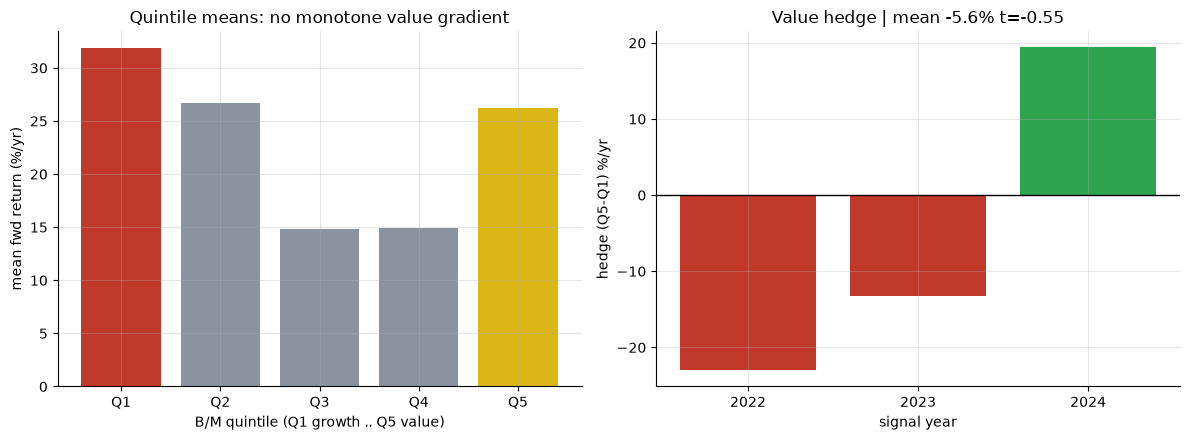

Hedge: -5.62%/yr | HAC t = -0.554


In [4]:
if HAVE_REAL:
    hedge_m, hedge_t = s_hedge['mean']*100, s_hedge['tstat']
    qcols = [c for c in sort.columns if c.startswith('Q')]
    qmeans = sort[qcols].mean()*100
    annual = (sort['hedge']*100); annual.index = [int(y) for y in sort.index]
else:
    hedge_m, hedge_t = R['hedge_mean'], R['hedge_t']
    qmeans = pd.Series({'Q1': R['growth_leg'], 'Q5': R['value_leg']})
    annual = pd.Series(R['annual'])
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(qmeans.index, qmeans.values, color=[RED]+[GREY]*(len(qmeans)-2)+[AMBER] if len(qmeans)>2 else [RED, AMBER])
axes[0].set_ylabel('mean fwd return (%/yr)'); axes[0].set_xlabel('B/M quintile (Q1 growth .. Q5 value)')
axes[0].set_title('Quintile means: no monotone value gradient')
col_yr = [GREEN if v > 0 else RED for v in annual.values]
axes[1].bar(annual.index.astype(str), annual.values, color=col_yr)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_xlabel('signal year'); axes[1].set_ylabel('hedge (Q5-Q1) %/yr')
axes[1].set_title(f'Value hedge | mean {hedge_m:+.1f}% t={hedge_t:+.2f}')
plt.tight_layout(); plt.show()
print(f'Hedge: {hedge_m:+.2f}%/yr | HAC t = {hedge_t:+.3f}')

### 4d -- Label-shuffle placebo

Is the (negative) hedge distinguishable from noise? Permute the B/M labels within each year 2000 times and rebuild the null distribution of the mean hedge.

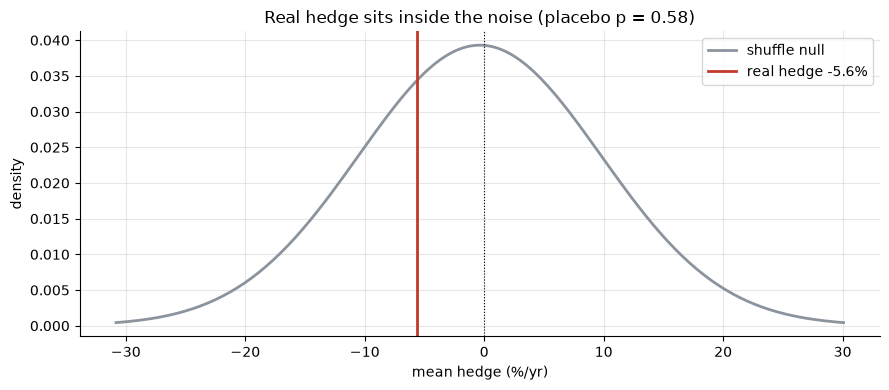

Real -5.62% | null -0.37% (std 10.15%) | p = 0.583


In [5]:
if HAVE_REAL:
    pb = st.placebo_pvalue(bm, fwd, n_shuffles=2000)
    real_m, null_m, null_s, pval = (pb['real_mean']*100, pb['null_mean']*100,
                                    pb['null_std']*100, pb['p_value'])
else:
    real_m, null_m, null_s, pval = (R['hedge_mean'], R['placebo_null_mean'],
                                    R['placebo_null_std'], R['placebo_p'])
x = np.linspace(null_m-3*null_s, null_m+3*null_s, 200)
fig, ax = plt.subplots(figsize=(9.0, 4.0))
from math import pi
ax.plot(x, np.exp(-0.5*((x-null_m)/null_s)**2)/(null_s*(2*pi)**.5), c=GREY, lw=2, label='shuffle null')
ax.axvline(real_m, c=RED, lw=2, label=f'real hedge {real_m:+.1f}%')
ax.axvline(0, c='k', lw=0.8, ls=':')
ax.set_xlabel('mean hedge (%/yr)'); ax.set_ylabel('density'); ax.legend()
ax.set_title(f'Real hedge sits inside the noise (placebo p = {pval:.2f})')
plt.tight_layout(); plt.show()
print(f'Real {real_m:+.2f}% | null {null_m:+.2f}% (std {null_s:.2f}%) | p = {pval:.3f}')

### 4e -- Costs: gross vs net

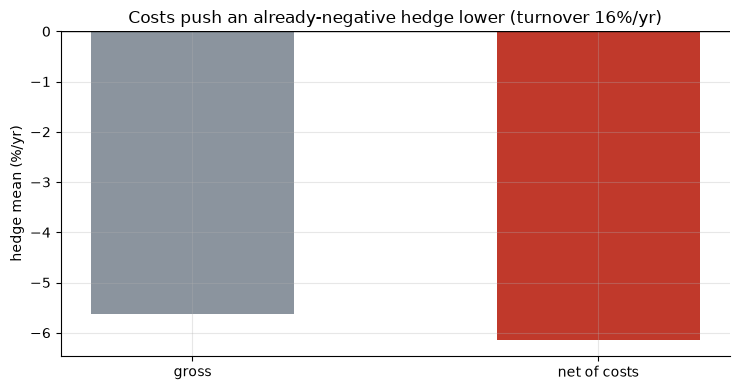

Turnover 15.6%/yr | cost 0.03% | borrow 0.50% | gross -5.62% -> net -6.15%


In [6]:
if HAVE_REAL:
    cs = st.apply_costs(sort, bm)
    turn, cd, bd = cs['avg_turnover']*100, cs['cost_drag']*100, cs['borrow_drag']*100
    gm, nm = cs['gross_mean']*100, cs['net_mean']*100
else:
    turn, cd, bd = R['turnover'], R['cost_drag'], R['borrow_drag']
    gm, nm = R['gross_mean'], R['net_mean']
fig, ax = plt.subplots(figsize=(7.5, 4.0))
ax.bar(['gross', 'net of costs'], [gm, nm], color=[GREY, RED], width=0.5)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('hedge mean (%/yr)')
ax.set_title(f'Costs push an already-negative hedge lower (turnover {turn:.0f}%/yr)')
plt.tight_layout(); plt.show()
print(f'Turnover {turn:.1f}%/yr | cost {cd:.2f}% | borrow {bd:.2f}% | '
      f'gross {gm:+.2f}% -> net {nm:+.2f}%')

## 5 -- The verdict

- **Signal `NONE`** -- hedge -5.62%/yr, HAC *t* = -0.554, placebo *p* = 0.583. Insignificant and the wrong sign; the Fama-French prior cannot rescue a negative real-tape result.
- **Tradability `MIRAGE`** -- net -6.15%/yr, Sharpe -0.253, on 3 annual observations. The thin fundamental history is the binding constraint.
- **Value survived? `BUSTED`** -- negative over the modern survivor window, even though the synthetic control is faithful and seed-robust.

## 6 -- Could you trade it?

No -- and not only because of the sign:

1. **Three annual cross-sections** is an anecdote, not a backtest. yfinance simply does not expose enough fundamental history for credible inference.
2. **Survivorship flatters the long leg**: bankrupt deep-value names (the natural value longs) are deleted, so even the negative result is an upper bound.
3. **Multi-year regime risk**: value underperformed for most of 2010-2020; the drawdown-tolerance required is extreme.

## 7 -- Going further

- **A real fundamentals database.** Compustat/CRSP with delistings, back to the 1920s, is where the premium actually lives -- and where the survivorship and sample-length limits here are fixed.
- **B/M sub-variants.** Operating-leverage-adjusted B/M, intangible-adjusted book value (a live debate on why value 'broke' post-2010).
- **Sibling value lenses on this desk:** [124 Cash-Flow-Yield](../../124-cash-flow-yield/), [121 Magic-Formula](../../121-magic-formula/), [243 Graham-NCAV](../../243-graham-ncav/).
- **Same machinery, different signal:** [238 Betting-Against-Beta](../../238-betting-against-beta/).

*Think value clears t > 2 net of costs on a survivorship-free, multi-decade panel? Fork this, swap in Compustat with delistings, and show it. That is the bar.*